 Mini Project: Dry Bean Type Classification

 Supervised Machine Learning Classification Project


 Objective

The objective of this project is to build a supervised machine learning model that can automatically classify different types of dry beans based on their physical characteristics such as area, perimeter, shape, compactness, eccentricity and other measurements.

The project will compare multiple classification algorithms and identify the best-performing model for bean classification.

1. Import and Load the Data
•	Import necessary libraries (pandas, numpy, matplotlib, seaborn, sklearn etc.)
•	Load the dataset and explore it using .head(), .info(), and .describe()


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:


df = pd.read_csv("Dry Beans Data.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 13611
Number of columns: 17


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

In [6]:
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860154,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [7]:
df['Class'].unique()

array(['SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'HOROZ', 'SIRA', 'DERMASON'],
      dtype=object)

In [8]:
df['Class'].value_counts()

Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

2. Exploratory Data Analysis (EDA)
•	Visualize distributions of features using histograms and boxplots
•	Analyze the class distribution (check for class imbalance)
•	Plot feature correlations (eg heatmap)
•	Visualize multivariate relationships (pairplot)
•	Summarize key findings


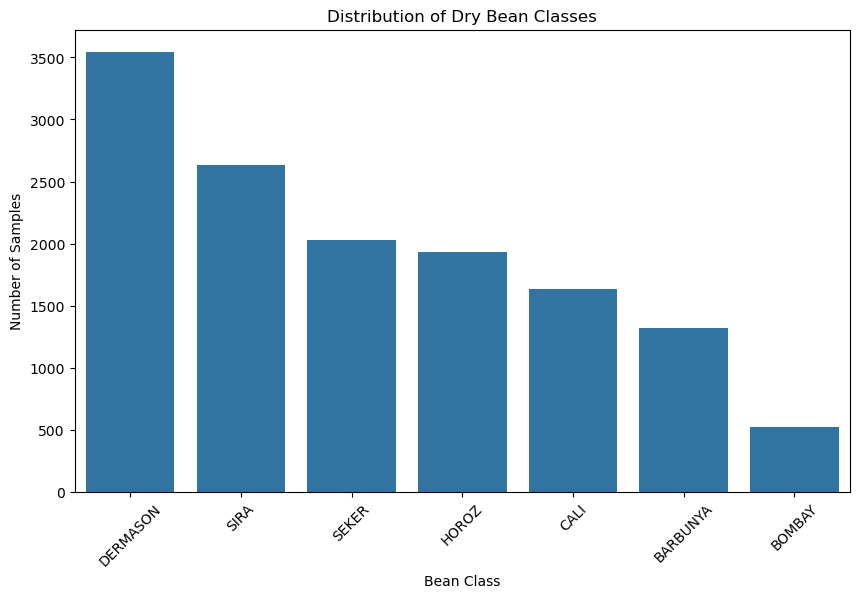

In [9]:
plt.figure(figsize=(10, 6))

sns.countplot(data=df, x='Class', order=df['Class'].value_counts().index)

plt.title('Distribution of Dry Bean Classes')
plt.xlabel('Bean Class')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)

plt.show()

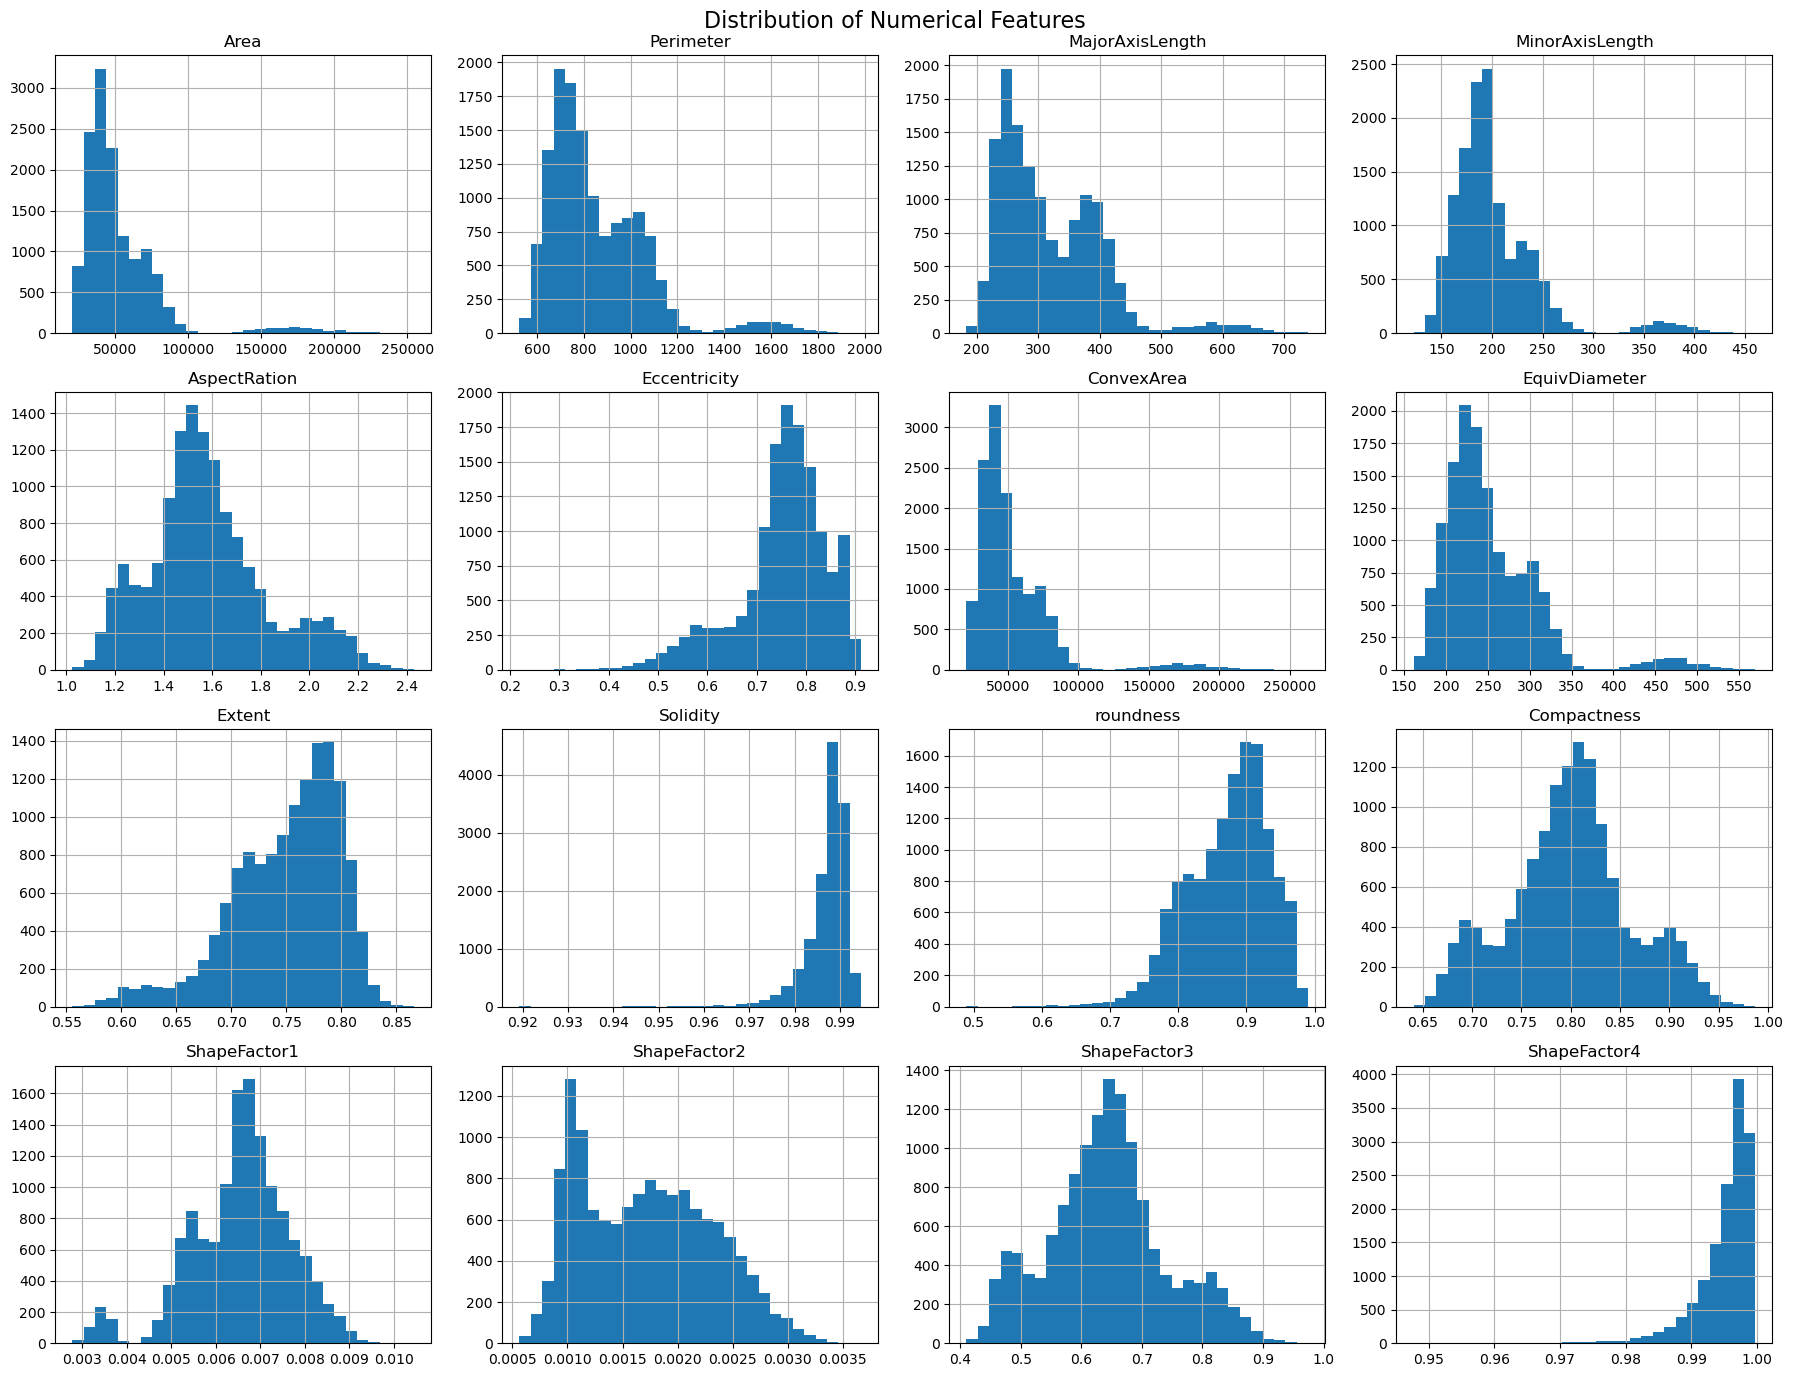

In [10]:
df.hist(figsize=(18, 14), bins=30)

plt.suptitle('Distribution of Numerical Features', fontsize=16)
plt.tight_layout()

plt.show()

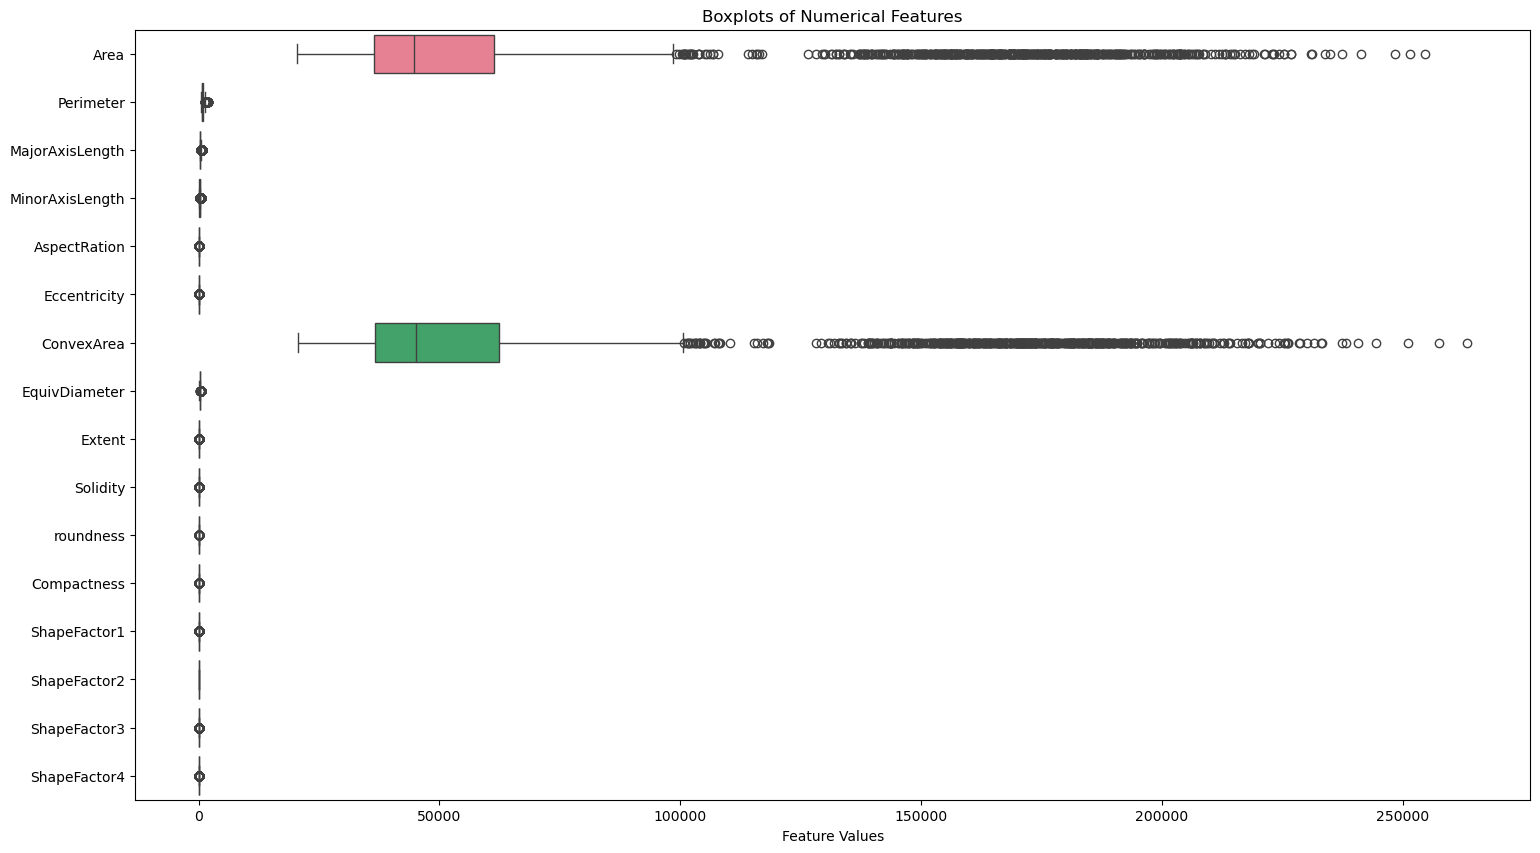

In [11]:
numeric_columns = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(18, 10))

sns.boxplot(data=df[numeric_columns], orient='h')

plt.title('Boxplots of Numerical Features')
plt.xlabel('Feature Values')

plt.show()

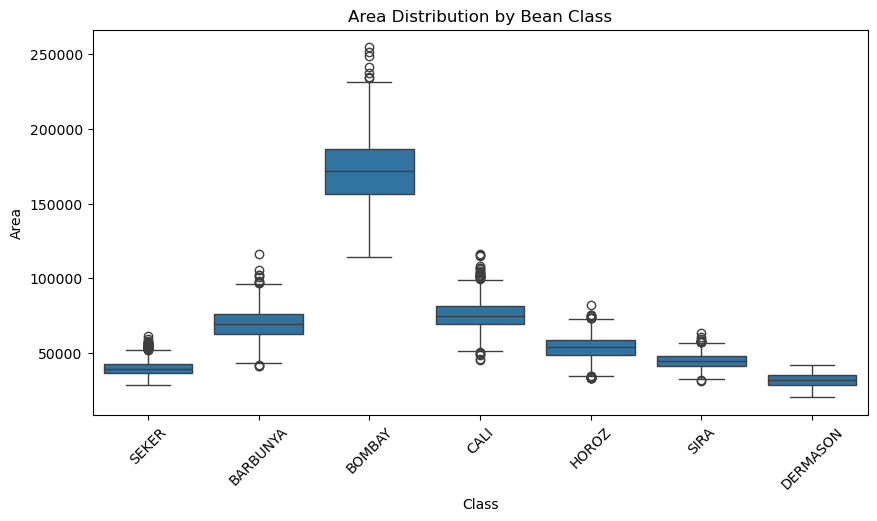

In [12]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df, x='Class', y='Area')

plt.title('Area Distribution by Bean Class')
plt.xticks(rotation=45)

plt.show()

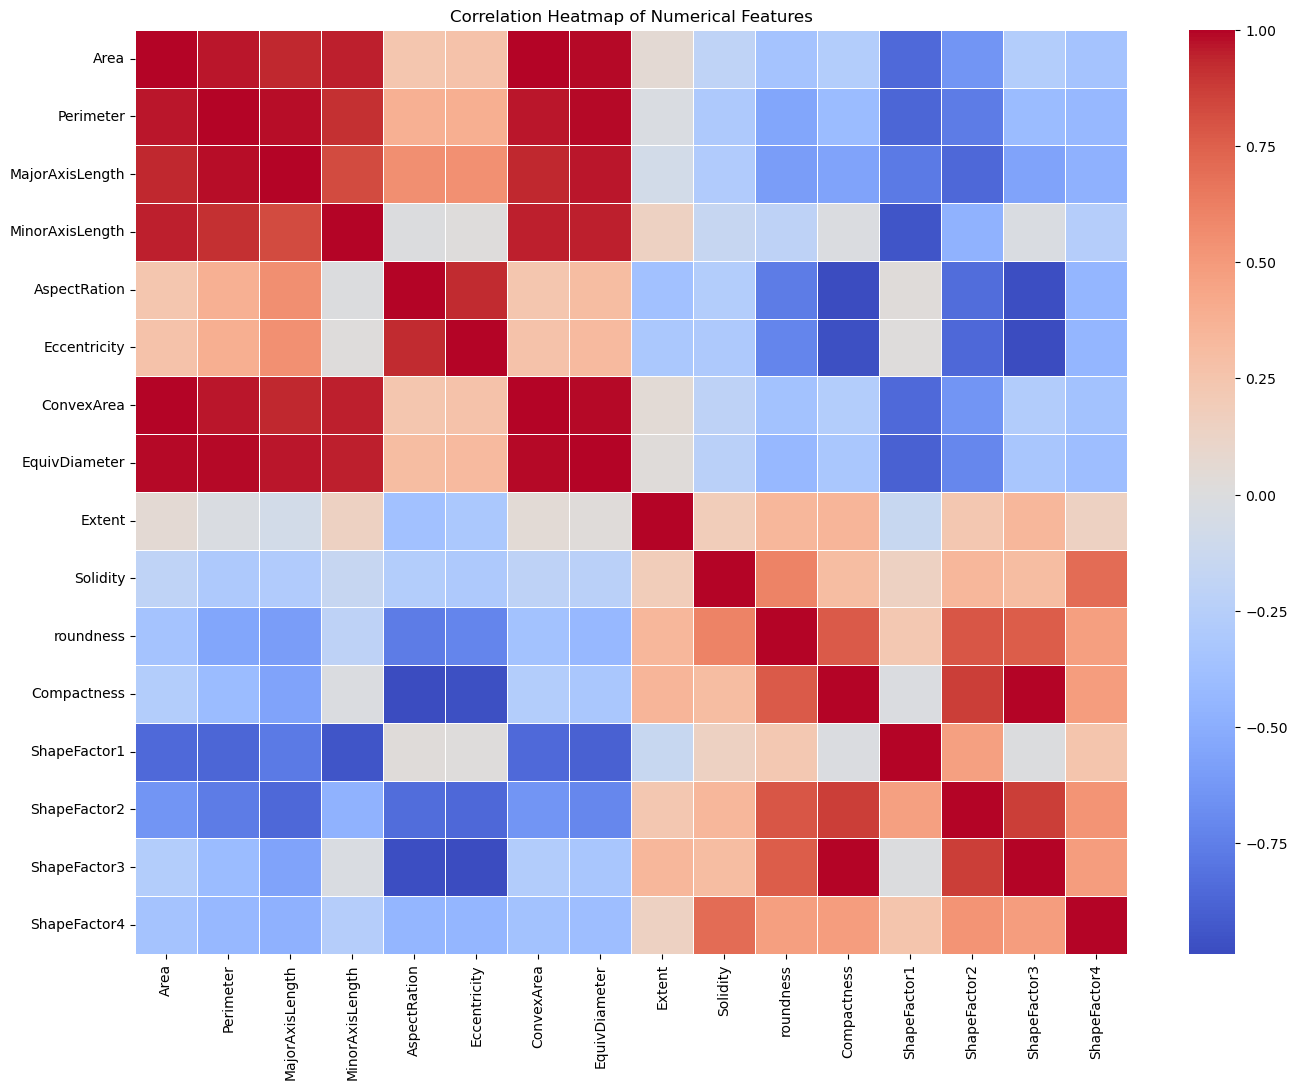

In [13]:
correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    annot=False,
    linewidths=0.5
)

plt.title('Correlation Heatmap of Numerical Features')

plt.show()

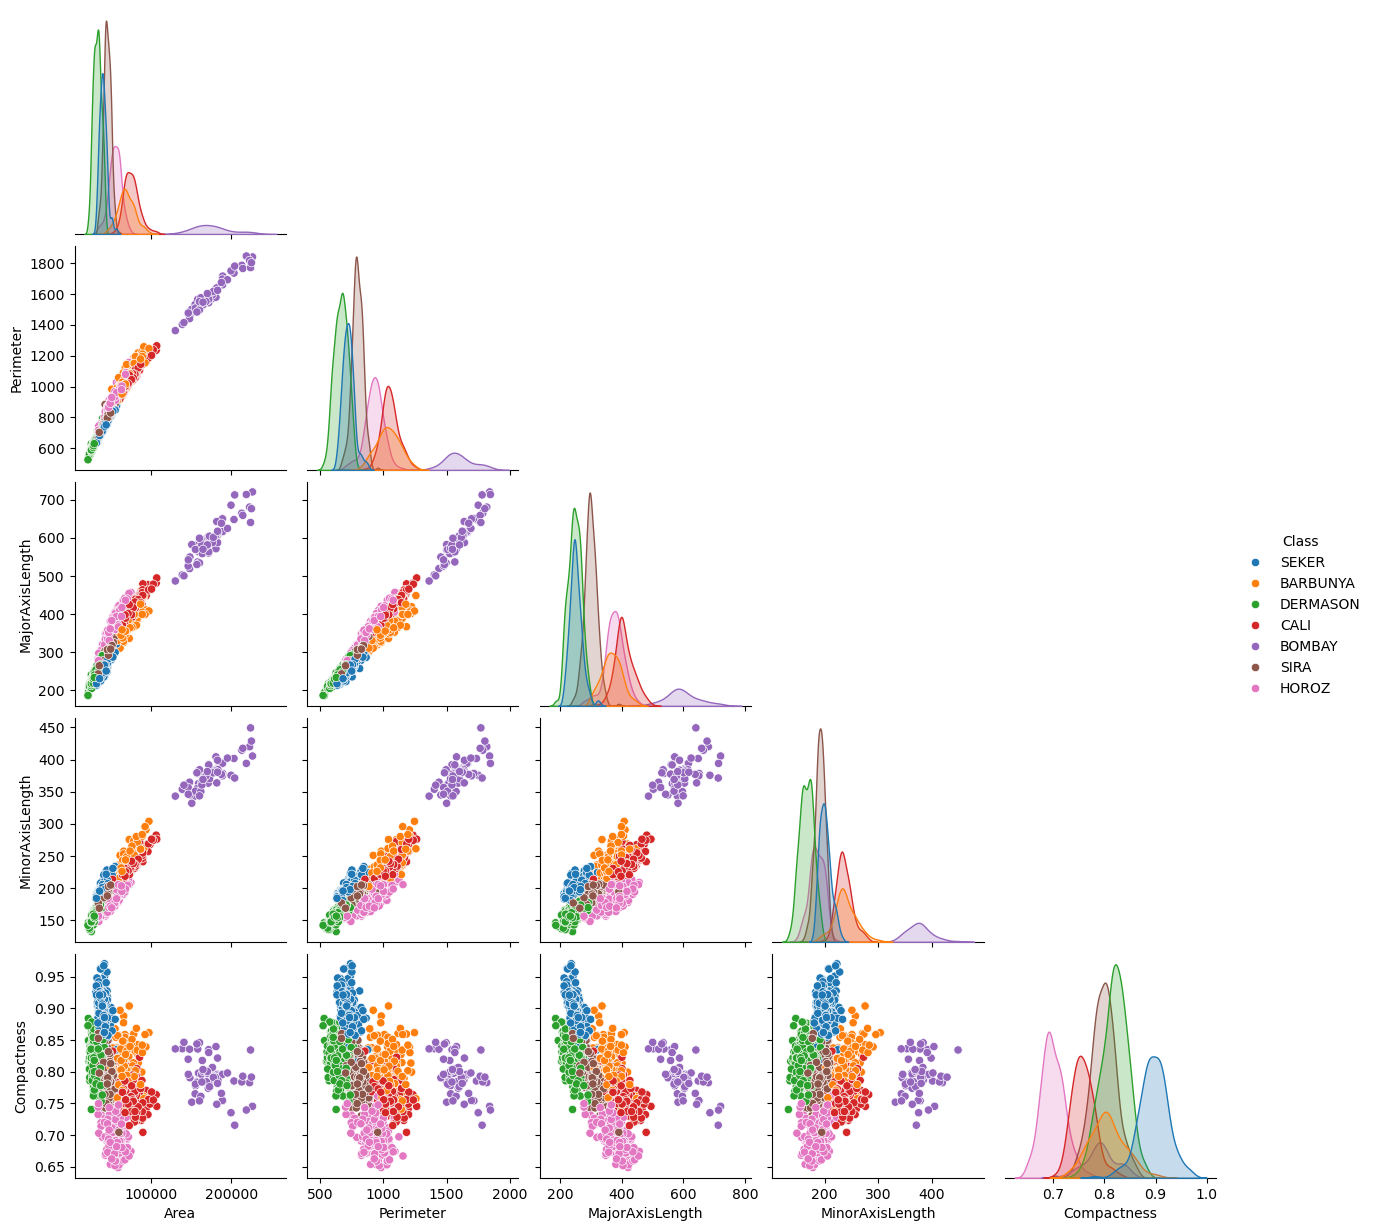

In [14]:
pairplot_sample = df.sample(n=1500, random_state=42)

sns.pairplot(
    pairplot_sample,
    vars=[
        'Area',
        'Perimeter',
        'MajorAxisLength',
        'MinorAxisLength',
        'Compactness'
    ],
    hue='Class',
    corner=True
)

plt.show()

 Key Findings from Exploratory Data Analysis (EDA)

1. The dataset contains **13,611 observations**, representing **7 different dry bean classes**: DERMASON, SIRA, SEKER, HOROZ, CALI, BARBUNYA and BOMBAY.

2. The class distribution is **imbalanced**. DERMASON has the highest number of observations (3,546), while BOMBAY has the lowest (522). Therefore, class imbalance should be considered during model development.

3. The numerical features have different distributions and measurement scales. Some features also show skewness, indicating that preprocessing and feature scaling may be useful before training certain machine learning models.

4. The boxplots indicate the presence of potential outliers in several numerical features. These outliers need to be examined before deciding whether treatment is required.

5. The correlation heatmap shows strong relationships among several features, particularly size-related measurements such as Area, Perimeter, MajorAxisLength and EquivDiameter.

6. The pairplot shows that some bean classes form distinguishable groups based on their physical characteristics, although there is also overlap between certain classes.

7. Overall, the EDA indicates that the physical and geometrical features contain useful patterns for distinguishing between different bean classes. Therefore, the dataset appears suitable for building supervised machine learning classification models.

3. Missing Values & Outlier Treatment
•	Check for and handle missing values
•	Detect and treat outliers if needed (Z-score / IQR methods/boxplots)


In [15]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64


In [16]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0




The dataset contains no missing values. Therefore, no missing-value imputation or row deletion is required.

In [17]:
Q1 = df[numeric_columns].quantile(0.25)
Q3 = df[numeric_columns].quantile(0.75)

IQR = Q3 - Q1

outliers = (
    (df[numeric_columns] < (Q1 - 1.5 * IQR)) |
    (df[numeric_columns] > (Q3 + 1.5 * IQR))
)

outlier_counts = outliers.sum().sort_values(ascending=False)

print("Potential outliers detected using IQR:")
print(outlier_counts)

Potential outliers detected using IQR:
Eccentricity       843
Solidity           778
ShapeFactor4       767
MinorAxisLength    569
Area               551
ConvexArea         550
ShapeFactor1       533
EquivDiameter      526
Perimeter          500
AspectRation       473
MajorAxisLength    379
Extent             275
ShapeFactor3       195
Compactness        109
roundness           91
ShapeFactor2         0
dtype: int64


4. Feature Engineering & Preprocessing
•	Scale numerical features (StandardScaler / MinMaxScaler)
•	Encode categorical variables if necessary
•	Check and treat skewness if required
•	Split data into train/test sets (use stratified sampling while splitting)


In [18]:
skewness = df[numeric_columns].skew().sort_values(ascending=False)

print("Skewness of numerical features:")
print(skewness)

Skewness of numerical features:
Area               2.952931
ConvexArea         2.941821
MinorAxisLength    2.238211
EquivDiameter      1.948958
Perimeter          1.626124
MajorAxisLength    1.357815
AspectRation       0.582573
ShapeFactor2       0.301226
ShapeFactor3       0.242481
Compactness        0.037115
ShapeFactor1      -0.534141
roundness         -0.635749
Extent            -0.895348
Eccentricity      -1.062824
Solidity          -2.550093
ShapeFactor4      -2.759483
dtype: float64


In [19]:
X = df.drop('Class', axis=1)
y = df['Class']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (13611, 16)
Shape of y: (13611,)


In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training features shape: (10888, 16)
Testing features shape: (2723, 16)
Training target shape: (10888,)
Testing target shape: (2723,)


In [22]:
print("Training class distribution (%):")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting class distribution (%):")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training class distribution (%):
Class
DERMASON    26.06
SIRA        19.37
SEKER       14.89
HOROZ       14.16
CALI        11.98
BARBUNYA     9.71
BOMBAY       3.84
Name: proportion, dtype: float64

Testing class distribution (%):
Class
DERMASON    26.04
SIRA        19.35
SEKER       14.91
HOROZ       14.18
CALI        11.97
BARBUNYA     9.73
BOMBAY       3.82
Name: proportion, dtype: float64


In [23]:
from sklearn.preprocessing import StandardScaler

In [24]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")
print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Feature scaling completed successfully!
Scaled training shape: (10888, 16)
Scaled testing shape: (2723, 16)


5. Model Building: Try Multiple Classifiers
Train and test the dataset on a variety of supervised classification algorithms:
•	Logistic Regression
•	Decision Tree Classifier
•	Random Forest Classifier
•	K-Nearest Neighbors (KNN)
•	Support Vector Machine (SVM)
•	Ensemble Learning Methods
•	Naive Bayes and more…
Use Cross validation techniques to check if model performance is improved.


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_model = LogisticRegression(max_iter=2000, random_state=42)

log_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [26]:
y_pred_log = log_model.predict(X_test_scaled)

print("First 10 actual classes:")
print(y_test.iloc[:10].values)

print("\nFirst 10 predicted classes:")
print(y_pred_log[:10])

First 10 actual classes:
['DERMASON' 'BOMBAY' 'SIRA' 'SEKER' 'BARBUNYA' 'SEKER' 'DERMASON' 'SIRA'
 'BARBUNYA' 'HOROZ']

First 10 predicted classes:
['DERMASON' 'BOMBAY' 'SIRA' 'SEKER' 'BARBUNYA' 'SEKER' 'DERMASON' 'SIRA'
 'CALI' 'HOROZ']


In [27]:
log_train_pred = log_model.predict(X_train_scaled)

log_train_accuracy = accuracy_score(y_train, log_train_pred)
log_test_accuracy = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Results")
print("---------------------------")
print(f"Training Accuracy: {log_train_accuracy:.4f}")
print(f"Testing Accuracy:  {log_test_accuracy:.4f}")

Logistic Regression Results
---------------------------
Training Accuracy: 0.9260
Testing Accuracy:  0.9207


In [28]:
print("Classification Report - Logistic Regression")
print("------------------------------------------------")

print(classification_report(y_test, y_pred_log))

Classification Report - Logistic Regression
------------------------------------------------
              precision    recall  f1-score   support

    BARBUNYA       0.95      0.89      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.94      0.94       326
    DERMASON       0.92      0.91      0.92       709
       HOROZ       0.96      0.95      0.96       386
       SEKER       0.93      0.95      0.94       406
        SIRA       0.85      0.88      0.86       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



In [29]:
from sklearn.metrics import f1_score

log_f1 = f1_score(y_test, y_pred_log, average='weighted')

print(f"Weighted F1 Score: {log_f1:.4f}")

Weighted F1 Score: 0.9209


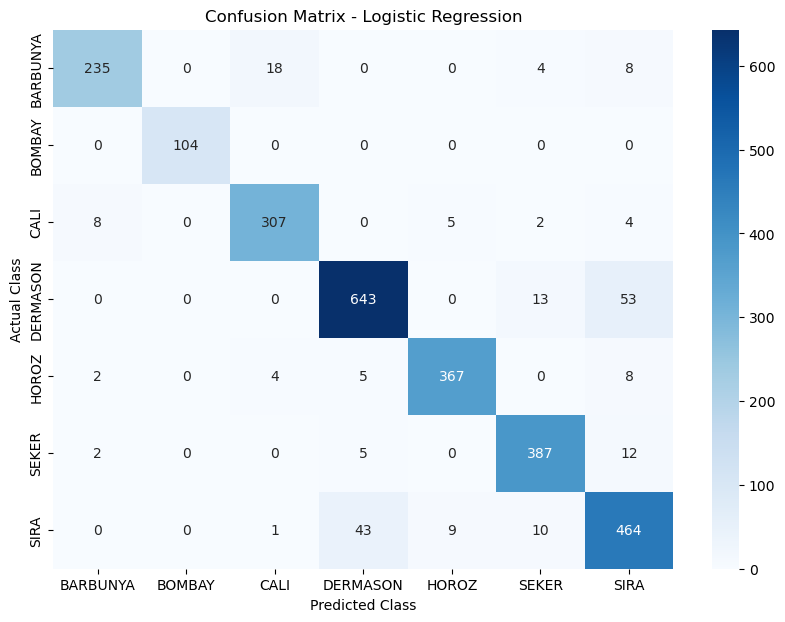

In [30]:
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(10, 7))

sns.heatmap(
    cm_log,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=log_model.classes_,
    yticklabels=log_model.classes_
)

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

plt.show()

In [31]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [32]:
y_pred_dt = dt_model.predict(X_test)

dt_train_pred = dt_model.predict(X_train)

dt_train_accuracy = accuracy_score(y_train, dt_train_pred)
dt_test_accuracy = accuracy_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt, average='weighted')

print("Decision Tree Results")
print("---------------------")
print(f"Training Accuracy: {dt_train_accuracy:.4f}")
print(f"Testing Accuracy:  {dt_test_accuracy:.4f}")
print(f"Weighted F1 Score: {dt_f1:.4f}")

Decision Tree Results
---------------------
Training Accuracy: 1.0000
Testing Accuracy:  0.8920
Weighted F1 Score: 0.8916


In [33]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [34]:
y_pred_rf = rf_model.predict(X_test)
rf_train_pred = rf_model.predict(X_train)

rf_train_accuracy = accuracy_score(y_train, rf_train_pred)
rf_test_accuracy = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')

print("Random Forest Results")
print("---------------------")
print(f"Training Accuracy: {rf_train_accuracy:.4f}")
print(f"Testing Accuracy:  {rf_test_accuracy:.4f}")
print(f"Weighted F1 Score: {rf_f1:.4f}")

Random Forest Results
---------------------
Training Accuracy: 1.0000
Testing Accuracy:  0.9203
Weighted F1 Score: 0.9203


In [35]:
print("Classification Report - Random Forest")
print("-------------------------------------")

print(classification_report(y_test, y_pred_rf))

Classification Report - Random Forest
-------------------------------------
              precision    recall  f1-score   support

    BARBUNYA       0.94      0.89      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.94      0.94       326
    DERMASON       0.90      0.92      0.91       709
       HOROZ       0.97      0.95      0.96       386
       SEKER       0.94      0.96      0.95       406
        SIRA       0.86      0.86      0.86       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



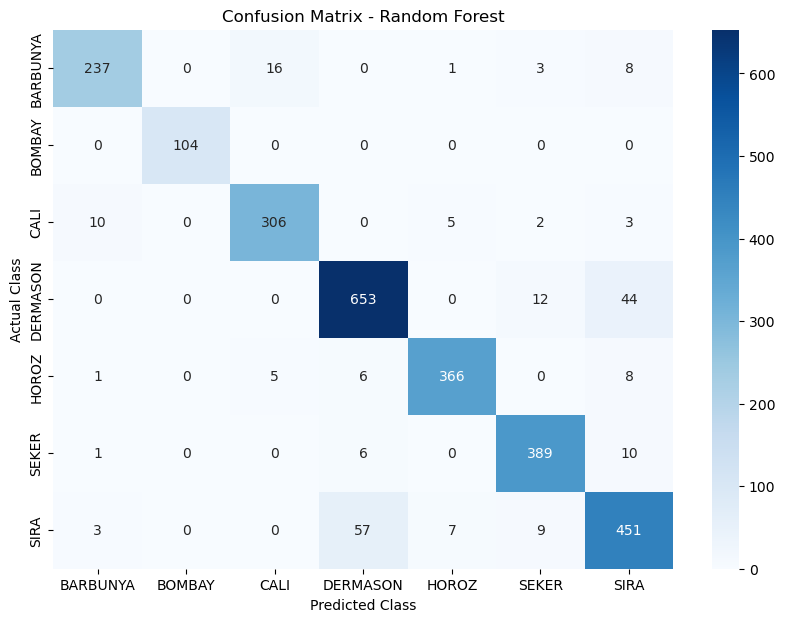

In [36]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(10, 7))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=rf_model.classes_,
    yticklabels=rf_model.classes_
)

plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

plt.show()

In [37]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

print("KNN model trained successfully!")

KNN model trained successfully!


In [38]:
y_pred_knn = knn_model.predict(X_test_scaled)
knn_train_pred = knn_model.predict(X_train_scaled)

knn_train_accuracy = accuracy_score(y_train, knn_train_pred)
knn_test_accuracy = accuracy_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn, average='weighted')

print("KNN Results")
print("-----------")
print(f"Training Accuracy: {knn_train_accuracy:.4f}")
print(f"Testing Accuracy:  {knn_test_accuracy:.4f}")
print(f"Weighted F1 Score: {knn_f1:.4f}")

KNN Results
-----------
Training Accuracy: 0.9415
Testing Accuracy:  0.9166
Weighted F1 Score: 0.9168


In [39]:
print("Classification Report - KNN")
print("---------------------------")

print(classification_report(y_test, y_pred_knn))

Classification Report - KNN
---------------------------
              precision    recall  f1-score   support

    BARBUNYA       0.95      0.88      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.94      0.93       326
    DERMASON       0.91      0.91      0.91       709
       HOROZ       0.95      0.95      0.95       386
       SEKER       0.95      0.94      0.95       406
        SIRA       0.84      0.87      0.86       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



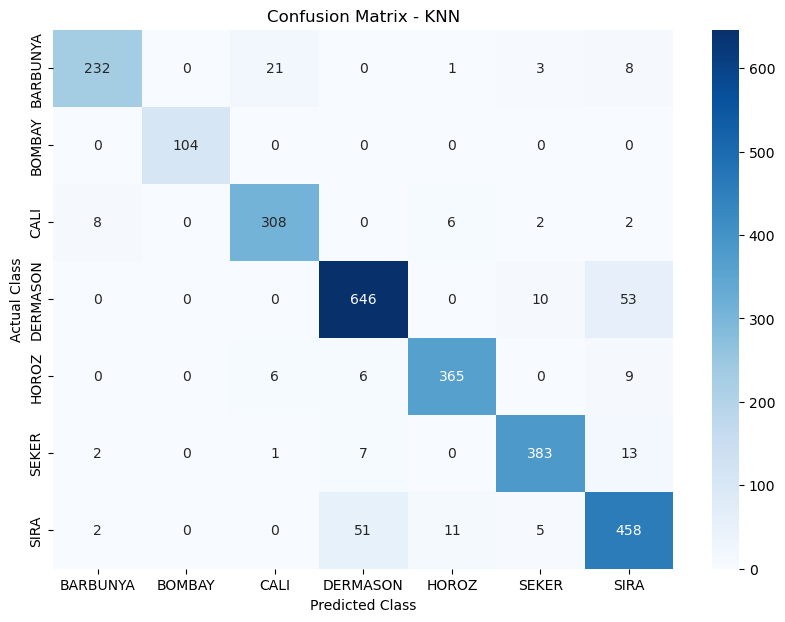

In [40]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(10, 7))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=knn_model.classes_,
    yticklabels=knn_model.classes_
)

plt.title('Confusion Matrix - KNN')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

plt.show()

In [41]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

print("SVM model trained successfully!")

SVM model trained successfully!


In [42]:
y_pred_svm = svm_model.predict(X_test_scaled)
svm_train_pred = svm_model.predict(X_train_scaled)

svm_train_accuracy = accuracy_score(y_train, svm_train_pred)
svm_test_accuracy = accuracy_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm, average='weighted')

print("SVM Results")
print("-----------")
print(f"Training Accuracy: {svm_train_accuracy:.4f}")
print(f"Testing Accuracy:  {svm_test_accuracy:.4f}")
print(f"Weighted F1 Score: {svm_f1:.4f}")

SVM Results
-----------
Training Accuracy: 0.9338
Testing Accuracy:  0.9221
Weighted F1 Score: 0.9222


In [43]:
print("Classification Report - SVM")
print("---------------------------")

print(classification_report(y_test, y_pred_svm))

Classification Report - SVM
---------------------------
              precision    recall  f1-score   support

    BARBUNYA       0.95      0.89      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.95      0.94       326
    DERMASON       0.92      0.91      0.91       709
       HOROZ       0.96      0.96      0.96       386
       SEKER       0.94      0.95      0.94       406
        SIRA       0.86      0.87      0.87       527

    accuracy                           0.92      2723
   macro avg       0.94      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



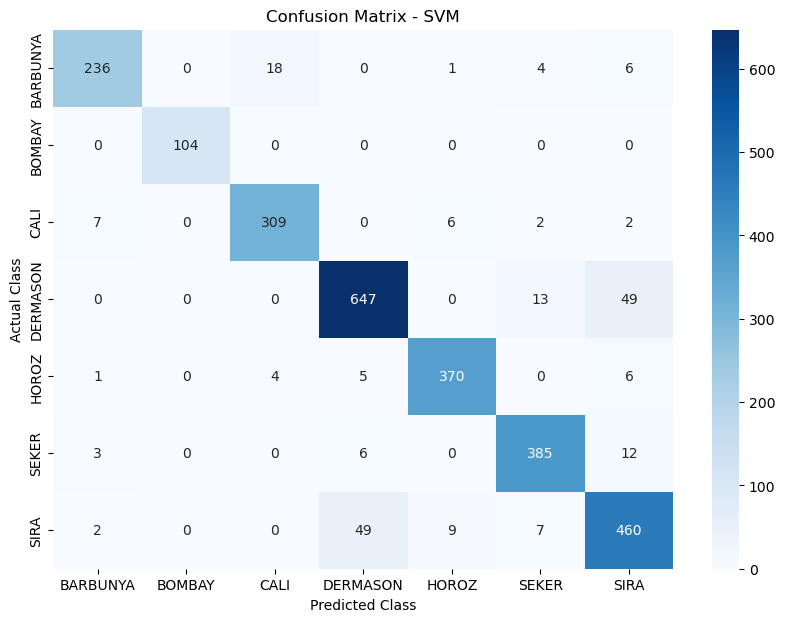

In [44]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(10, 7))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=svm_model.classes_,
    yticklabels=svm_model.classes_
)

plt.title('Confusion Matrix - SVM')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

plt.show()

In [45]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(X_train_scaled, y_train)

print("Gaussian Naive Bayes model trained successfully!")

Gaussian Naive Bayes model trained successfully!


In [46]:
y_pred_nb = nb_model.predict(X_test_scaled)
nb_train_pred = nb_model.predict(X_train_scaled)

nb_train_accuracy = accuracy_score(y_train, nb_train_pred)
nb_test_accuracy = accuracy_score(y_test, y_pred_nb)
nb_f1 = f1_score(y_test, y_pred_nb, average='weighted')

print("Naive Bayes Results")
print("-------------------")
print(f"Training Accuracy: {nb_train_accuracy:.4f}")
print(f"Testing Accuracy:  {nb_test_accuracy:.4f}")
print(f"Weighted F1 Score: {nb_f1:.4f}")

Naive Bayes Results
-------------------
Training Accuracy: 0.8975
Testing Accuracy:  0.8979
Weighted F1 Score: 0.8981


In [47]:
print("Classification Report - Gaussian Naive Bayes")
print("---------------------------------------------")

print(classification_report(y_test, y_pred_nb))

Classification Report - Gaussian Naive Bayes
---------------------------------------------
              precision    recall  f1-score   support

    BARBUNYA       0.90      0.80      0.85       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.86      0.92      0.89       326
    DERMASON       0.93      0.86      0.90       709
       HOROZ       0.95      0.95      0.95       386
       SEKER       0.92      0.94      0.93       406
        SIRA       0.81      0.89      0.84       527

    accuracy                           0.90      2723
   macro avg       0.91      0.91      0.91      2723
weighted avg       0.90      0.90      0.90      2723



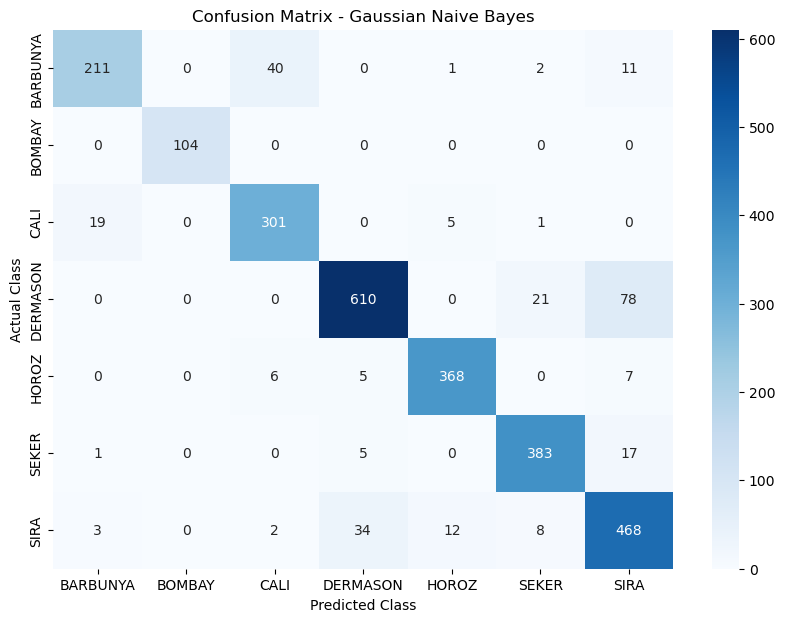

In [48]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(10, 7))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=nb_model.classes_,
    yticklabels=nb_model.classes_
)

plt.title('Confusion Matrix - Gaussian Naive Bayes')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

plt.show()

In [49]:
from sklearn.ensemble import VotingClassifier

voting_model = VotingClassifier(
    estimators=[
        ('logistic', LogisticRegression(max_iter=2000, random_state=42)),
        ('random_forest', RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        )),
        ('svm', SVC(kernel='rbf', C=1.0, gamma='scale'))
    ],
    voting='hard'
)

voting_model.fit(X_train_scaled, y_train)

print("Voting Classifier trained successfully!")

Voting Classifier trained successfully!


In [50]:
y_pred_voting = voting_model.predict(X_test_scaled)
voting_train_pred = voting_model.predict(X_train_scaled)

voting_train_accuracy = accuracy_score(y_train, voting_train_pred)
voting_test_accuracy = accuracy_score(y_test, y_pred_voting)
voting_f1 = f1_score(y_test, y_pred_voting, average='weighted')

print("Voting Classifier Results")
print("-------------------------")
print(f"Training Accuracy: {voting_train_accuracy:.4f}")
print(f"Testing Accuracy:  {voting_test_accuracy:.4f}")
print(f"Weighted F1 Score: {voting_f1:.4f}")

Voting Classifier Results
-------------------------
Training Accuracy: 0.9423
Testing Accuracy:  0.9218
Weighted F1 Score: 0.9218


In [51]:
print("Classification Report - Voting Classifier")
print("-----------------------------------------")

print(classification_report(y_test, y_pred_voting))

Classification Report - Voting Classifier
-----------------------------------------
              precision    recall  f1-score   support

    BARBUNYA       0.94      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.94      0.94       326
    DERMASON       0.92      0.92      0.92       709
       HOROZ       0.96      0.96      0.96       386
       SEKER       0.93      0.95      0.94       406
        SIRA       0.86      0.87      0.87       527

    accuracy                           0.92      2723
   macro avg       0.94      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



In [52]:
print(f"Logistic Regression F1: {log_f1:.4f}")

Logistic Regression F1: 0.9209


In [53]:
baseline_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'KNN',
        'SVM',
        'Gaussian Naive Bayes',
        'Voting Classifier'
    ],
    
    'Train Accuracy': [
        log_train_accuracy,
        dt_train_accuracy,
        rf_train_accuracy,
        knn_train_accuracy,
        svm_train_accuracy,
        nb_train_accuracy,
        voting_train_accuracy
    ],
    
    'Test Accuracy': [
        log_test_accuracy,
        dt_test_accuracy,
        rf_test_accuracy,
        knn_test_accuracy,
        svm_test_accuracy,
        nb_test_accuracy,
        voting_test_accuracy
    ],
    
    'Weighted F1 Score': [
        log_f1,
        dt_f1,
        rf_f1,
        knn_f1,
        svm_f1,
        nb_f1,
        voting_f1
    ]
})

baseline_results

,Model,Train Accuracy,Test Accuracy,Weighted F1 Score
0,Logistic Regression,0.925974,0.920676,0.920873
1,Decision Tree,1.000000,0.892031,0.891630
2,Random Forest,1.000000,0.920308,0.920283
3,KNN,0.941495,0.916636,0.916805
4,SVM,0.933780,0.922145,0.922177
5,Gaussian Naive Bayes,0.897502,0.897907,0.898075
6,Voting Classifier,0.942322,0.921777,0.921811


In [54]:
baseline_results['Train-Test Gap'] = (
    baseline_results['Train Accuracy'] -
    baseline_results['Test Accuracy']
)

baseline_results['Overfitting'] = baseline_results['Train-Test Gap'].apply(
    lambda x: 'Yes' if x > 0.05 else 'No'
)

baseline_results = baseline_results.sort_values(
    by='Test Accuracy',
    ascending=False
).reset_index(drop=True)

baseline_results

,Model,Train Accuracy,Test Accuracy,Weighted F1 Score,Train-Test Gap,Overfitting
0,SVM,0.933780,0.922145,0.922177,0.011636,No
1,Voting Classifier,0.942322,0.921777,0.921811,0.020544,No
2,Logistic Regression,0.925974,0.920676,0.920873,0.005298,No
3,Random Forest,1.000000,0.920308,0.920283,0.079692,Yes
4,KNN,0.941495,0.916636,0.916805,0.024859,No
5,Gaussian Naive Bayes,0.897502,0.897907,0.898075,-0.000405,No
6,Decision Tree,1.000000,0.892031,0.891630,0.107969,Yes


In [55]:
display_results = baseline_results.copy()

for column in [
    'Train Accuracy',
    'Test Accuracy',
    'Weighted F1 Score',
    'Train-Test Gap'
]:
    display_results[column] = (
        display_results[column] * 100
    ).round(2)

display_results

,Model,Train Accuracy,Test Accuracy,Weighted F1 Score,Train-Test Gap,Overfitting
0,SVM,93.38,92.21,92.22,1.16,No
1,Voting Classifier,94.23,92.18,92.18,2.05,No
2,Logistic Regression,92.60,92.07,92.09,0.53,No
3,Random Forest,100.00,92.03,92.03,7.97,Yes
4,KNN,94.15,91.66,91.68,2.49,No
5,Gaussian Naive Bayes,89.75,89.79,89.81,-0.04,No
6,Decision Tree,100.00,89.20,89.16,10.80,Yes


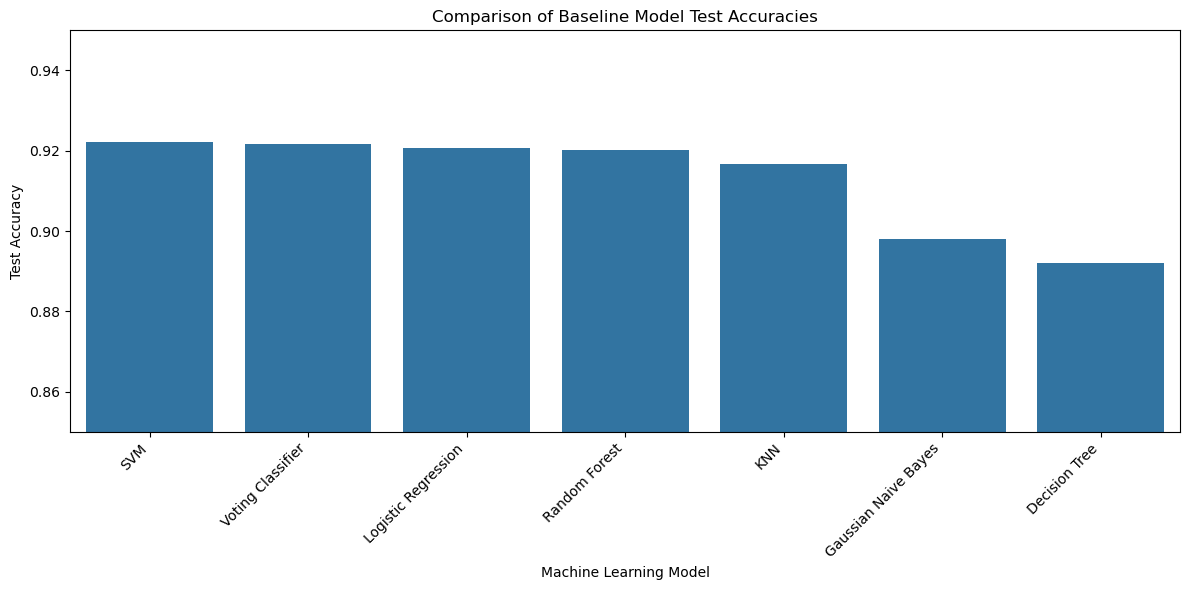

In [56]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=baseline_results,
    x='Model',
    y='Test Accuracy'
)

plt.title('Comparison of Baseline Model Test Accuracies')
plt.xlabel('Machine Learning Model')
plt.ylabel('Test Accuracy')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.85, 0.95)

plt.tight_layout()
plt.show()

 Baseline Model Comparison - Key Findings

Seven supervised classification approaches were evaluated.

- **SVM** achieved the highest baseline testing accuracy and weighted F1-score.
- **Voting Classifier, Logistic Regression and Random Forest** also achieved highly competitive performance.
- **KNN** performed well but was slightly below the leading models.
- **Gaussian Naive Bayes** showed consistent training and testing performance but lower overall predictive accuracy.
- The unrestricted **Decision Tree showed substantial overfitting**, achieving perfect training accuracy but considerably lower testing accuracy.
- Since several models have very similar test performance, test accuracy alone is not sufficient to declare the final best model.

Therefore, cross-validation will next be used to evaluate model stability across multiple subsets of the training data.

In [57]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-fold Stratified Cross-Validation configured successfully!")

5-fold Stratified Cross-Validation configured successfully!


In [58]:
from sklearn.pipeline import make_pipeline

log_cv_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, random_state=42)
)

log_cv_scores = cross_val_score(
    log_cv_model,
    X_train,
    y_train,
    cv=cv,
    scoring='accuracy'
)

print("Logistic Regression CV Scores:")
print(log_cv_scores)

print(f"\nMean CV Accuracy: {log_cv_scores.mean():.4f}")
print(f"CV Standard Deviation: {log_cv_scores.std():.4f}")

Logistic Regression CV Scores:
[0.92929293 0.92745638 0.91781451 0.92282958 0.92191089]

Mean CV Accuracy: 0.9239
CV Standard Deviation: 0.0041


In [59]:
svm_cv_model = make_pipeline(
    StandardScaler(),
    SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale'
    )
)

svm_cv_scores = cross_val_score(
    svm_cv_model,
    X_train,
    y_train,
    cv=cv,
    scoring='accuracy'
)

print("SVM CV Scores:")
print(svm_cv_scores)

print(f"\nMean CV Accuracy: {svm_cv_scores.mean():.4f}")
print(f"CV Standard Deviation: {svm_cv_scores.std():.4f}")

SVM CV Scores:
[0.93434343 0.93801653 0.92561983 0.92650436 0.9288011 ]

Mean CV Accuracy: 0.9307
CV Standard Deviation: 0.0048


In [60]:
svm_cv_model = make_pipeline(
    StandardScaler(),
    SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale'
    )
)

svm_cv_scores = cross_val_score(
    svm_cv_model,
    X_train,
    y_train,
    cv=cv,
    scoring='accuracy'
)

print("SVM CV Scores:")
print(svm_cv_scores)

print(f"\nMean CV Accuracy: {svm_cv_scores.mean():.4f}")
print(f"CV Standard Deviation: {svm_cv_scores.std():.4f}")

SVM CV Scores:
[0.93434343 0.93801653 0.92561983 0.92650436 0.9288011 ]

Mean CV Accuracy: 0.9307
CV Standard Deviation: 0.0048




Five-fold stratified cross-validation was performed to evaluate the stability and generalization of the leading models.

- Logistic Regression achieved a mean cross-validation accuracy of **92.39%** with a standard deviation of **0.41%**.
- Support Vector Machine (SVM) achieved a higher mean cross-validation accuracy of **93.07%** with a standard deviation of **0.48%**.

Both models show low variation across the five folds, indicating stable performance. SVM achieved the higher average cross-validation accuracy and therefore remains the strongest-performing model at this stage.

However, the final model will not yet be selected because class imbalance and hyperparameter tuning still need to be evaluated.

6. Handling Class Imbalance
•	Apply techniques like:
o	SMOTE (Synthetic Minority Over-sampling)
o	Random Oversampling / Undersampling
o	Class weighting
•	Evaluate if performance improves on minority classes


In [61]:
from imblearn.over_sampling import SMOTE

print("SMOTE imported successfully!")

SMOTE imported successfully!


In [62]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Original training data shape:", X_train.shape)
print("SMOTE training data shape:", X_train_smote.shape)

Original training data shape: (10888, 16)
SMOTE training data shape: (19859, 16)


In [63]:
print("Class distribution BEFORE SMOTE:")
print(y_train.value_counts())

print("\nClass distribution AFTER SMOTE:")
print(y_train_smote.value_counts())

Class distribution BEFORE SMOTE:
Class
DERMASON    2837
SIRA        2109
SEKER       1621
HOROZ       1542
CALI        1304
BARBUNYA    1057
BOMBAY       418
Name: count, dtype: int64

Class distribution AFTER SMOTE:
Class
SEKER       2837
HOROZ       2837
CALI        2837
SIRA        2837
DERMASON    2837
BARBUNYA    2837
BOMBAY      2837
Name: count, dtype: int64


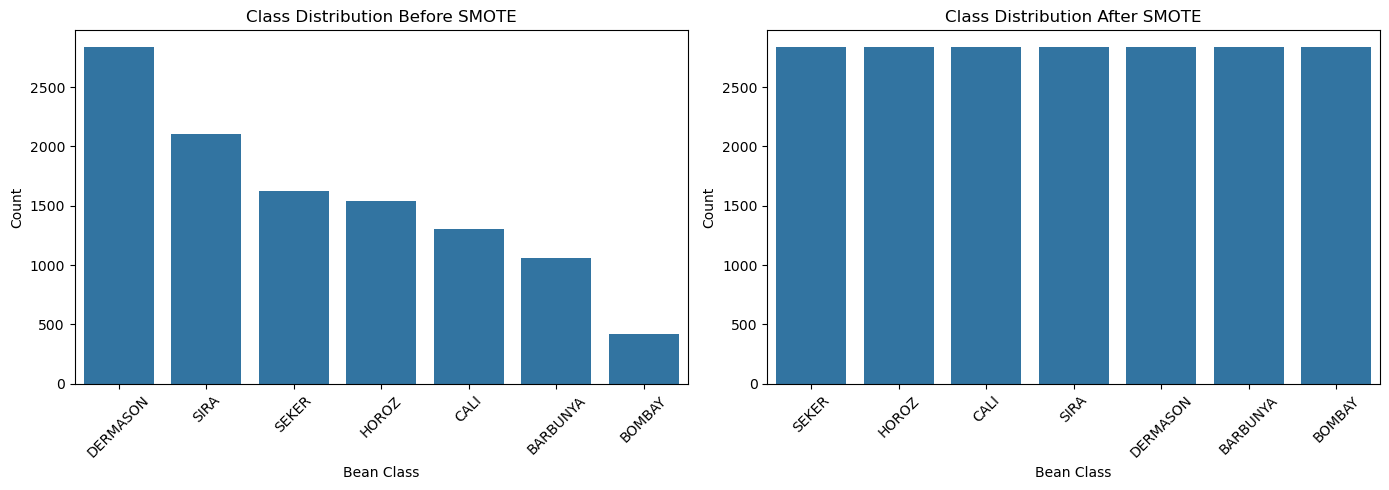

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    x=y_train,
    order=y_train.value_counts().index,
    ax=axes[0]
)

axes[0].set_title("Class Distribution Before SMOTE")
axes[0].set_xlabel("Bean Class")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)


sns.countplot(
    x=y_train_smote,
    order=y_train_smote.value_counts().index,
    ax=axes[1]
)

axes[1].set_title("Class Distribution After SMOTE")
axes[1].set_xlabel("Bean Class")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [65]:
smote_scaler = StandardScaler()

X_train_smote_scaled = smote_scaler.fit_transform(X_train_smote)

X_test_smote_scaled = smote_scaler.transform(X_test)

print("SMOTE training data scaled successfully!")
print("Training shape:", X_train_smote_scaled.shape)
print("Testing shape:", X_test_smote_scaled.shape)

SMOTE training data scaled successfully!
Training shape: (19859, 16)
Testing shape: (2723, 16)


In [67]:
from sklearn.preprocessing import StandardScaler

smote_scaler = StandardScaler()

X_train_smote_scaled = smote_scaler.fit_transform(X_train_smote)

X_test_smote_scaled = smote_scaler.transform(X_test)

print("SMOTE training data scaled successfully!")
print("Training shape:", X_train_smote_scaled.shape)
print("Testing shape:", X_test_smote_scaled.shape)

SMOTE training data scaled successfully!
Training shape: (19859, 16)
Testing shape: (2723, 16)


In [68]:
svm_smote_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=42
)

svm_smote_model.fit(
    X_train_smote_scaled,
    y_train_smote
)

print("SVM with SMOTE trained successfully!")

SVM with SMOTE trained successfully!


In [69]:
y_pred_svm_smote = svm_smote_model.predict(X_test_smote_scaled)

svm_smote_test_accuracy = accuracy_score(
    y_test,
    y_pred_svm_smote
)

svm_smote_f1 = f1_score(
    y_test,
    y_pred_svm_smote,
    average='weighted'
)

print("SVM with SMOTE Results")
print("----------------------")
print(f"Test Accuracy: {svm_smote_test_accuracy:.4f}")
print(f"Weighted F1 Score: {svm_smote_f1:.4f}")

SVM with SMOTE Results
----------------------
Test Accuracy: 0.9243
Weighted F1 Score: 0.9245


In [70]:
print("Classification Report - SVM with SMOTE")
print("--------------------------------------")

print(classification_report(y_test, y_pred_svm_smote))

Classification Report - SVM with SMOTE
--------------------------------------
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.92      0.93       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.94      0.94       326
    DERMASON       0.94      0.90      0.92       709
       HOROZ       0.96      0.96      0.96       386
       SEKER       0.93      0.96      0.94       406
        SIRA       0.85      0.89      0.87       527

    accuracy                           0.92      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.93      0.92      0.92      2723



 Effect of SMOTE on Model Performance

SMOTE was applied only to the training dataset to address class imbalance, while the original test dataset was kept unchanged for unbiased evaluation.

The baseline SVM achieved a testing accuracy of **92.21%** and a weighted F1-score of **92.22%**. After applying SMOTE, the SVM achieved a testing accuracy of **92.43%** and a weighted F1-score of **92.45%**.

Thus, SMOTE produced a small improvement in overall model performance.

The class-wise evaluation also showed strong performance for the minority classes. In particular, BOMBAY achieved a precision, recall and F1-score of **1.00**, while BARBUNYA achieved an F1-score of **0.93**.

The macro-average F1-score of **0.94** indicates strong performance across the seven classes, including the less frequent classes.

Therefore, SMOTE was useful for handling class imbalance and the SMOTE-balanced SVM will be considered for further model optimization.

8. Hyperparameter Tuning
•	Use GridSearchCV or RandomizedSearchCV to optimize parameters for top-performing models
•	Document the best parameters and performance improvement


 Hyperparameter Tuning

The SVM model demonstrated the strongest overall baseline and cross-validation performance. Its performance also improved after addressing class imbalance using SMOTE.

Therefore, GridSearchCV is used to optimize important SVM hyperparameters, particularly **C**, **gamma**, and **kernel**.

GridSearchCV systematically evaluates different combinations of hyperparameters using cross-validation and selects the combination that produces the best validation performance.

In [71]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.1],
    'kernel': ['rbf']
}

svm_grid = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(X_train_smote_scaled, y_train_smote)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': ['scale', 0.01, 0.1],
                         'kernel': ['rbf']},
             scoring='f1_weighted', verbose=1)

In [72]:
print("Best SVM Parameters:")
print(svm_grid.best_params_)

print("\nBest Cross-Validation Weighted F1 Score:")
print(f"{svm_grid.best_score_:.4f}")

Best SVM Parameters:
{'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}

Best Cross-Validation Weighted F1 Score:
0.9543


In [73]:
best_svm_model = svm_grid.best_estimator_

y_pred_tuned_svm = best_svm_model.predict(X_test_smote_scaled)

tuned_svm_accuracy = accuracy_score(y_test, y_pred_tuned_svm)
tuned_svm_f1 = f1_score(y_test, y_pred_tuned_svm, average='weighted')

print("Tuned SVM Results")
print("-----------------")
print(f"Test Accuracy: {tuned_svm_accuracy:.4f}")
print(f"Weighted F1 Score: {tuned_svm_f1:.4f}")

Tuned SVM Results
-----------------
Test Accuracy: 0.9240
Weighted F1 Score: 0.9239


In [74]:
print("Classification Report - Tuned SVM")
print("---------------------------------")
print(classification_report(y_test, y_pred_tuned_svm))

Classification Report - Tuned SVM
---------------------------------
              precision    recall  f1-score   support

    BARBUNYA       0.94      0.93      0.93       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.94      0.94       326
    DERMASON       0.92      0.91      0.92       709
       HOROZ       0.95      0.95      0.95       386
       SEKER       0.94      0.96      0.95       406
        SIRA       0.87      0.86      0.87       527

    accuracy                           0.92      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.92      0.92      0.92      2723



In [75]:
final_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'KNN',
        'SVM',
        'Gaussian Naive Bayes',
        'Voting Classifier',
        'SVM + SMOTE',
        'Tuned SVM + SMOTE'
    ],
    'Test Accuracy': [
        log_test_accuracy,
        dt_test_accuracy,
        rf_test_accuracy,
        knn_test_accuracy,
        svm_test_accuracy,
        nb_test_accuracy,
        voting_test_accuracy,
        svm_smote_test_accuracy,
        tuned_svm_accuracy
    ],
    'Weighted F1 Score': [
        log_f1,
        dt_f1,
        rf_f1,
        knn_f1,
        svm_f1,
        nb_f1,
        voting_f1,
        svm_smote_f1,
        tuned_svm_f1
    ]
})

final_comparison = final_comparison.sort_values(
    by='Weighted F1 Score',
    ascending=False
).reset_index(drop=True)

final_comparison

,Model,Test Accuracy,Weighted F1 Score
0,SVM + SMOTE,0.924348,0.924476
1,Tuned SVM + SMOTE,0.923981,0.923879
2,SVM,0.922145,0.922177
3,Voting Classifier,0.921777,0.921811
4,Logistic Regression,0.920676,0.920873
5,Random Forest,0.920308,0.920283
6,KNN,0.916636,0.916805
7,Gaussian Naive Bayes,0.897907,0.898075
8,Decision Tree,0.892031,0.891630


In [76]:
svm_smote_train_pred = svm_smote_model.predict(X_train_smote_scaled)

svm_smote_train_accuracy = accuracy_score(
    y_train_smote,
    svm_smote_train_pred
)

print(f"SVM + SMOTE Training Accuracy: {svm_smote_train_accuracy:.4f}")

SVM + SMOTE Training Accuracy: 0.9516


In [77]:
tuned_svm_train_pred = best_svm_model.predict(X_train_smote_scaled)

tuned_svm_train_accuracy = accuracy_score(
    y_train_smote,
    tuned_svm_train_pred
)

print(f"Tuned SVM + SMOTE Training Accuracy: {tuned_svm_train_accuracy:.4f}")

Tuned SVM + SMOTE Training Accuracy: 0.9648


In [78]:
final_model_table = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'KNN',
        'SVM',
        'Gaussian Naive Bayes',
        'Voting Classifier',
        'SVM + SMOTE',
        'Tuned SVM + SMOTE'
    ],
    'Train Accuracy': [
        log_train_accuracy,
        dt_train_accuracy,
        rf_train_accuracy,
        knn_train_accuracy,
        svm_train_accuracy,
        nb_train_accuracy,
        voting_train_accuracy,
        svm_smote_train_accuracy,
        tuned_svm_train_accuracy
    ],
    'Test Accuracy': [
        log_test_accuracy,
        dt_test_accuracy,
        rf_test_accuracy,
        knn_test_accuracy,
        svm_test_accuracy,
        nb_test_accuracy,
        voting_test_accuracy,
        svm_smote_test_accuracy,
        tuned_svm_accuracy
    ],
    'Weighted F1 Score': [
        log_f1,
        dt_f1,
        rf_f1,
        knn_f1,
        svm_f1,
        nb_f1,
        voting_f1,
        svm_smote_f1,
        tuned_svm_f1
    ]
})

final_model_table['Overfitting'] = (
    (final_model_table['Train Accuracy'] -
     final_model_table['Test Accuracy']) > 0.05
).map({True: 'Yes', False: 'No'})

final_model_table = final_model_table.sort_values(
    'Weighted F1 Score',
    ascending=False
).reset_index(drop=True)

final_model_table

,Model,Train Accuracy,Test Accuracy,Weighted F1 Score,Overfitting
0,SVM + SMOTE,0.951558,0.924348,0.924476,No
1,Tuned SVM + SMOTE,0.964751,0.923981,0.923879,No
2,SVM,0.933780,0.922145,0.922177,No
3,Voting Classifier,0.942322,0.921777,0.921811,No
4,Logistic Regression,0.925974,0.920676,0.920873,No
5,Random Forest,1.000000,0.920308,0.920283,Yes
6,KNN,0.941495,0.916636,0.916805,No
7,Gaussian Naive Bayes,0.897502,0.897907,0.898075,No
8,Decision Tree,1.000000,0.892031,0.891630,Yes


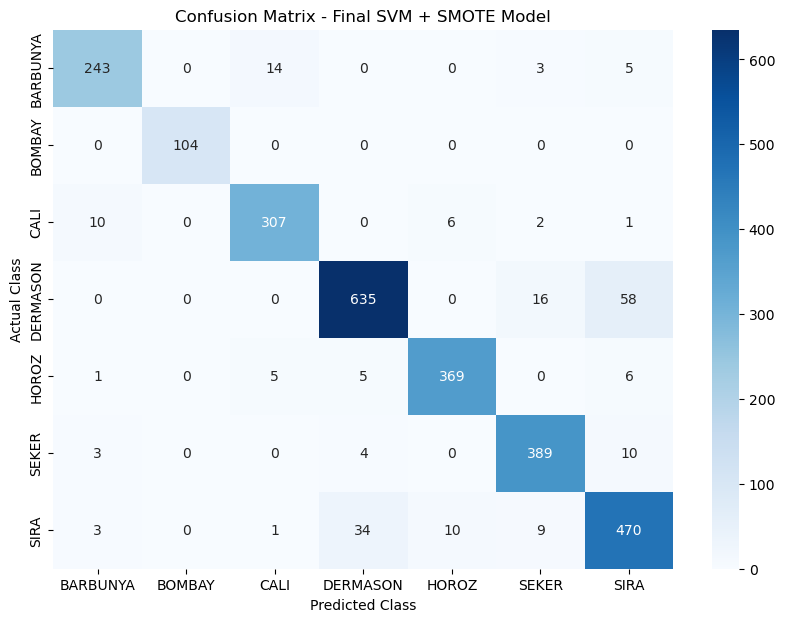

In [79]:
cm_final = confusion_matrix(y_test, y_pred_svm_smote)

plt.figure(figsize=(10, 7))

sns.heatmap(
    cm_final,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=svm_smote_model.classes_,
    yticklabels=svm_smote_model.classes_
)

plt.title('Confusion Matrix - Final SVM + SMOTE Model')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

plt.show()

 Final Model Selection

After evaluating multiple classification algorithms, **SVM with SMOTE** was selected as the final model.

The model achieved a **training accuracy of 95.16%**, **test accuracy of 92.43%**, and **weighted F1-score of 92.45%**. The relatively small difference between training and testing performance indicates good generalization without substantial overfitting.

The baseline SVM achieved a test accuracy of 92.21% and weighted F1-score of 92.22%. After applying SMOTE to address class imbalance, performance improved to 92.43% test accuracy and 92.45% weighted F1-score.

Hyperparameter tuning using GridSearchCV identified C = 100, gamma = 0.1 and an RBF kernel, with a cross-validation weighted F1-score of 95.43%. However, the tuned model achieved 92.40% test accuracy and 92.39% weighted F1-score on the untouched test dataset, which was slightly lower than the untuned SVM with SMOTE.

Therefore, the **SVM with SMOTE** model was selected because it produced the best overall performance on unseen test data while maintaining strong class-wise performance and good generalization.

In [80]:
import joblib

joblib.dump(svm_smote_model, "dry_bean_svm_model.pkl")
joblib.dump(smote_scaler, "dry_bean_scaler.pkl")

print("Final model and scaler saved successfully!")

Final model and scaler saved successfully!


In [81]:
loaded_model = joblib.load("dry_bean_svm_model.pkl")
loaded_scaler = joblib.load("dry_bean_scaler.pkl")

print("Model loaded successfully:", type(loaded_model))
print("Scaler loaded successfully:", type(loaded_scaler))

Model loaded successfully: <class 'sklearn.svm._classes.SVC'>
Scaler loaded successfully: <class 'sklearn.preprocessing._data.StandardScaler'>


In [82]:
print("Features used by the model:")
for i, feature in enumerate(X.columns, start=1):
    print(i, feature)

Features used by the model:
1 Area
2 Perimeter
3 MajorAxisLength
4 MinorAxisLength
5 AspectRation
6 Eccentricity
7 ConvexArea
8 EquivDiameter
9 Extent
10 Solidity
11 roundness
12 Compactness
13 ShapeFactor1
14 ShapeFactor2
15 ShapeFactor3
16 ShapeFactor4


In [83]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

st.set_page_config(
    page_title="Dry Bean Classifier",
    page_icon="🌱",
    layout="centered"
)

st.title("🌱 Dry Bean Type Classification")
st.write(
    "This application predicts the type of dry bean "
    "based on its physical and geometrical characteristics."
)

st.success("Application interface loaded successfully!")

Overwriting app.py


In [84]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

st.set_page_config(
    page_title="Dry Bean Classifier",
    page_icon="🌱",
    layout="centered"
)

# Load trained model and scaler
model = joblib.load("dry_bean_svm_model.pkl")
scaler = joblib.load("dry_bean_scaler.pkl")

st.title("🌱 Dry Bean Type Classification")

st.write(
    "This application predicts the type of dry bean "
    "based on its physical and geometrical characteristics."
)

st.success("Machine Learning model loaded successfully!")

Overwriting app.py


In [85]:
print(X.median())

Area               44652.000000
Perimeter            794.941000
MajorAxisLength      296.883367
MinorAxisLength      192.431733
AspectRation           1.551124
Eccentricity           0.764441
ConvexArea         45178.000000
EquivDiameter        238.438026
Extent                 0.759859
Solidity               0.988283
roundness              0.883157
Compactness            0.801277
ShapeFactor1           0.006645
ShapeFactor2           0.001694
ShapeFactor3           0.642044
ShapeFactor4           0.996386
dtype: float64


In [86]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

st.set_page_config(
    page_title="Dry Bean Classifier",
    page_icon="🌱",
    layout="centered"
)

model = joblib.load("dry_bean_svm_model.pkl")
scaler = joblib.load("dry_bean_scaler.pkl")

st.title("🌱 Dry Bean Type Classification")

st.write(
    "Enter the physical and geometrical measurements of a dry bean "
    "to predict its class."
)

st.subheader("Enter Bean Measurements")

Area = st.number_input("Area", value=44652.0)
Perimeter = st.number_input("Perimeter", value=794.941)
MajorAxisLength = st.number_input("Major Axis Length", value=296.883367)
MinorAxisLength = st.number_input("Minor Axis Length", value=192.431733)
AspectRation = st.number_input("Aspect Ratio", value=1.551124)
Eccentricity = st.number_input("Eccentricity", value=0.764441)
ConvexArea = st.number_input("Convex Area", value=45178.0)
EquivDiameter = st.number_input("Equivalent Diameter", value=238.438026)
Extent = st.number_input("Extent", value=0.759859)
Solidity = st.number_input("Solidity", value=0.988283)
roundness = st.number_input("Roundness", value=0.883157)
Compactness = st.number_input("Compactness", value=0.801277)
ShapeFactor1 = st.number_input("Shape Factor 1", value=0.006645)
ShapeFactor2 = st.number_input("Shape Factor 2", value=0.001694)
ShapeFactor3 = st.number_input("Shape Factor 3", value=0.642044)
ShapeFactor4 = st.number_input("Shape Factor 4", value=0.996386)

Overwriting app.py


In [87]:
%%writefile -a app.py

if st.button("Predict Bean Class"):

    input_data = pd.DataFrame([[
        Area,
        Perimeter,
        MajorAxisLength,
        MinorAxisLength,
        AspectRation,
        Eccentricity,
        ConvexArea,
        EquivDiameter,
        Extent,
        Solidity,
        roundness,
        Compactness,
        ShapeFactor1,
        ShapeFactor2,
        ShapeFactor3,
        ShapeFactor4
    ]], columns=[
        'Area',
        'Perimeter',
        'MajorAxisLength',
        'MinorAxisLength',
        'AspectRation',
        'Eccentricity',
        'ConvexArea',
        'EquivDiameter',
        'Extent',
        'Solidity',
        'roundness',
        'Compactness',
        'ShapeFactor1',
        'ShapeFactor2',
        'ShapeFactor3',
        'ShapeFactor4'
    ])

    scaled_data = scaler.transform(input_data)

    prediction = model.predict(scaled_data)[0]

    st.success(f"Predicted Bean Class: {prediction}")

Appending to app.py


In [88]:
!streamlit run app.py

^C


 Final Conclusion and Recommendations

This project developed a machine learning solution for classifying seven varieties of dry beans using their physical and geometrical characteristics.

Multiple classification algorithms were evaluated, including Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors, Support Vector Machine, Gaussian Naive Bayes, and a Voting Classifier. Class imbalance was addressed using SMOTE.

Among the evaluated models, **SVM with SMOTE** provided the best overall performance on the unseen test dataset, achieving:

- **Training Accuracy:** 95.16%
- **Test Accuracy:** 92.43%
- **Weighted F1-Score:** 92.45%

Hyperparameter tuning was also performed using GridSearchCV. Although the tuned SVM achieved a strong cross-validation weighted F1-score of 95.43%, its test performance was marginally lower than the untuned SVM with SMOTE. Therefore, SVM with SMOTE was selected as the final model.

 Recommendations

The developed model can support automated bean classification and sorting based on measurable physical characteristics. It may help reduce manual classification effort and improve consistency in agricultural and food-processing environments.

For practical deployment, model performance should be monitored on new batches of beans, particularly for classes that show greater overlap with other varieties. Human quality checks can also be retained for uncertain or difficult samples.

Limitations and Future Scope

The model has been developed using the available Dry Bean dataset and should be validated on additional real-world data before large-scale deployment. Future work could include collecting more samples, testing additional feature-engineering techniques, and evaluating advanced ensemble or boosting algorithms.

Finally, a **Streamlit application** was developed to allow users to enter the physical measurements of a bean and obtain its predicted bean class through a simple interactive interface.

In [89]:
%%writefile requirements.txt
streamlit
pandas
scikit-learn
joblib
openpyxl
imbalanced-learn

Overwriting requirements.txt


In [ ]:
import os

print("Files in project folder:")
for file in os.listdir("."):
    print(file)

In [91]:
import os

os.makedirs("Dry_Bean_GitHub_Project", exist_ok=True)

print("Clean GitHub project folder created successfully!")

Clean GitHub project folder created successfully!


In [92]:
import shutil

shutil.copy("app.py", "Dry_Bean_GitHub_Project/app.py")

print("app.py copied successfully!")

app.py copied successfully!


In [93]:
import shutil

shutil.copy(
    "dry_bean_svm_model.pkl",
    "Dry_Bean_GitHub_Project/dry_bean_svm_model.pkl"
)

print("Trained SVM model copied successfully!")

Trained SVM model copied successfully!


In [94]:
import shutil

shutil.copy(
    "dry_bean_scaler.pkl",
    "Dry_Bean_GitHub_Project/dry_bean_scaler.pkl"
)

print("Scaler copied successfully!")

Scaler copied successfully!


In [95]:
import shutil

shutil.copy(
    "requirements.txt",
    "Dry_Bean_GitHub_Project/requirements.txt"
)

print("requirements.txt copied successfully!")

requirements.txt copied successfully!


In [97]:
import os

for file in os.listdir("."):
    if file.endswith(".ipynb") and "Bean" in file:
        print(file)

In [98]:
import os
from datetime import datetime

notebooks = []

for file in os.listdir("."):
    if file.endswith(".ipynb"):
        modified = os.path.getmtime(file)
        notebooks.append((file, modified))

for file, modified in sorted(notebooks, key=lambda x: x[1], reverse=True)[:10]:
    print(datetime.fromtimestamp(modified).strftime("%d-%m-%Y %H:%M:%S"), " | ", file)

06-10-2026 19:38:44  |  Himani Supervised ML Classification Mini Project.ipynb
05-10-2026 23:04:18  |  Himani Verma Image Classification Using CNN Mini Project.ipynb
04-10-2026 17:26:40  |  Himani Verma Supervised ML Classification Mini Project.ipynb
04-10-2026 00:46:46  |  Himani Verma Supervised ML Mini Project.ipynb
04-10-2026 00:09:06  |  Himani Verma EDA Mini Project.ipynb
03-10-2026 23:34:16  |  Himani Verma NLP, RNN Assignment.ipynb
02-10-2026 23:43:55  |  Himani Verma Unsupervised Machine Learning Assignment.ipynb
02-10-2026 22:31:13  |  Himani Verma Supervised Machine Learning Assignment.ipynb
02-10-2026 15:49:14  |  Untitled3.ipynb
01-10-2026 14:44:59  |  Supervised ML Decision Tree.ipynb
